In [1]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import v_measure_score

from datasets import load_dataset

/Users/manya/Downloads/mopb/mopb-clustering/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ds = load_dataset("tattabio/mopb_clustering")["train"]
true_labels = pd.Series(ds["Label"])
print(true_labels)

0       DmsA
1       DmsA
2       DmsA
3       DmsA
4       DmsA
        ... 
1295      AH
1296      AH
1297      AH
1298      AH
1299      AH
Length: 1300, dtype: str


In [3]:
df = pd.read_csv("kmer_matrix.csv")
df.head()

,AAA,AAC,AAD,AAE,AAF,AAG,AAH,AAI,AAK,AAL,...,YYM,YYN,YYP,YYQ,YYR,YYS,YYT,YYV,YYW,YYY
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,1,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
3,2,0,1,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


## K-means Clustering

In [4]:
v_measures = []
for i in range(10):
    kmeans = KMeans(n_clusters=13, random_state=i, n_init="auto").fit(df)
    kmeans_labels = kmeans.labels_
    v_measures.append(v_measure_score(true_labels, kmeans_labels))

In [5]:
# this prints only the most recent cluster assignments
print(pd.crosstab(np.array(true_labels), np.array(kmeans_labels), rownames=['True'], colnames=['Cluster']))
# this averages v-measures across the 10 iterations
print(sum(v_measures) / len(v_measures))
results_v_measures = [{'KMeans (Avg)': sum(v_measures) / len(v_measures)}]

Cluster   0   1   2   3    4   5   6   7   8   9    10  11  12
True                                                          
AH         0   0   0   1   99   0   0   0   0   0    0   0   0
ActB       0   0   0   0   94   0   0   0   0   0    0   0   6
DmsA       2   0   0   0   97   0   0   0   0   0    1   0   0
DorATorA   0   0   0   0   22   0   0   0   0   0   78   0   0
FdhG       0   0   0   0   99   0   0   0   0   0    0   1   0
Fdhs       0   0   0   0   96   0   0   0   0   0    4   0   0
FwdB       0   0   0   0    0   0   0   0   0   0  100   0   0
NapA       0   0   0   0   47   0   0   0   0  53    0   0   0
NarG       0  72   0   0    0   0   0  28   0   0    0   0   0
NasCNarB   0   0  10   0   34   0  56   0   0   0    0   0   0
Nqo3       0   0   0   0    0   0   0   0   0   0  100   0   0
PsrAPhsA   0   0   0   0  100   0   0   0   0   0    0   0   0
TtrASrdA   0   0   1   0   91   2   0   0   6   0    0   0   0
0.5641910248591511


## Hierarchical/Agglomerative Clustering

In [6]:
# Ward linkage
agg_ward = AgglomerativeClustering(n_clusters=13, metric='euclidean', linkage='ward').fit(df)
agg_ward_labels = agg_ward.labels_

In [7]:
print(pd.crosstab(np.array(true_labels), np.array(agg_ward_labels), rownames=['True'], colnames=['Cluster']))
print(v_measure_score(true_labels, agg_ward_labels))
results_v_measures.append({'Agglomerative (Ward)': v_measure_score(true_labels, agg_ward_labels)})

Cluster   0    1   2   3    4   5   6    7   8   9    10  11  12
True                                                            
AH         0  100   0   0    0   0   0    0   0   0    0   0   0
ActB       0    0   0   0  100   0   0    0   0   0    0   0   0
DmsA       0  100   0   0    0   0   0    0   0   0    0   0   0
DorATorA   0   23   0   0    0   0   0    0   0   0    0  77   0
FdhG      81    0   0  19    0   0   0    0   0   0    0   0   0
Fdhs       0    2   0  73    0   0   0   25   0   0    0   0   0
FwdB       0    0   0   0    0   0   0    0   0   0  100   0   0
NapA       0    1   0  46    0   0   0    0   0  53    0   0   0
NarG       0    0   0   0    0  25   0    0  52   0    0   0  23
NasCNarB   0    0   0  44    0   0  56    0   0   0    0   0   0
Nqo3       0    0   0   0    0   0   0  100   0   0    0   0   0
PsrAPhsA   0  100   0   0    0   0   0    0   0   0    0   0   0
TtrASrdA   0    0  98   2    0   0   0    0   0   0    0   0   0
0.8168470826709578


In [8]:
# Complete linkage
agg_complete = AgglomerativeClustering(n_clusters=13, metric='euclidean', linkage='complete').fit(df)
agg_complete_labels = agg_complete.labels_

In [9]:
print(pd.crosstab(np.array(true_labels), np.array(agg_complete_labels), rownames=['True'], colnames=['Cluster']))
print(v_measure_score(true_labels, agg_complete_labels))
results_v_measures.append({'Agglomerative (Complete)': v_measure_score(true_labels, agg_complete_labels)})

Cluster   0   1   2    3   4   5   6   7   8   9   10  11  12
True                                                         
AH         0   0   0  100   0   0   0   0   0   0   0   0   0
ActB       0   0   0    9   0   0  56   0   0   2   0   0  33
DmsA       0   0   0  100   0   0   0   0   0   0   0   0   0
DorATorA   0   0   0  100   0   0   0   0   0   0   0   0   0
FdhG       0   0   0   19  81   0   0   0   0   0   0   0   0
Fdhs       0   0   0  100   0   0   0   0   0   0   0   0   0
FwdB       0   0   0  100   0   0   0   0   0   0   0   0   0
NapA       0   0   0  100   0   0   0   0   0   0   0   0   0
NarG      24  21   0    0   0  28   0   0  27   0   0   0   0
NasCNarB   0   0   0  100   0   0   0   0   0   0   0   0   0
Nqo3       0   0   0  100   0   0   0   0   0   0   0   0   0
PsrAPhsA   0   0   0  100   0   0   0   0   0   0   0   0   0
TtrASrdA   0   0  60    2   0   0   0  24   0   0  11   3   0
0.48693453204559917


In [10]:
# Average linkage
agg_avg = AgglomerativeClustering(n_clusters=13, metric='euclidean', linkage='average').fit(df)
agg_avg_labels = agg_avg.labels_

In [11]:
print(pd.crosstab(np.array(true_labels), np.array(agg_avg_labels), rownames=['True'], colnames=['Cluster']))
print(v_measure_score(true_labels, agg_avg_labels))
results_v_measures.append({'Agglomerative (Average)': v_measure_score(true_labels, agg_avg_labels)})

Cluster    0   1   2   3   4   5   6   7   8   9   10  11  12
True                                                         
AH        100   0   0   0   0   0   0   0   0   0   0   0   0
ActB       98   0   0   0   0   0   0   0   0   2   0   0   0
DmsA      100   0   0   0   0   0   0   0   0   0   0   0   0
DorATorA  100   0   0   0   0   0   0   0   0   0   0   0   0
FdhG      100   0   0   0   0   0   0   0   0   0   0   0   0
Fdhs      100   0   0   0   0   0   0   0   0   0   0   0   0
FwdB      100   0   0   0   0   0   0   0   0   0   0   0   0
NapA      100   0   0   0   0   0   0   0   0   0   0   0   0
NarG        0  22  20  22   4  28   1   1   1   0   0   0   1
NasCNarB  100   0   0   0   0   0   0   0   0   0   0   0   0
Nqo3      100   0   0   0   0   0   0   0   0   0   0   0   0
PsrAPhsA  100   0   0   0   0   0   0   0   0   0   0   0   0
TtrASrdA   95   0   0   0   0   0   0   0   0   0   3   2   0
0.18961906011575477


In [12]:
# Single linkage
agg_single = AgglomerativeClustering(n_clusters=13, metric='euclidean', linkage='single').fit(df)
agg_single_labels = agg_single.labels_

In [13]:
print(pd.crosstab(np.array(true_labels), np.array(agg_single_labels), rownames=['True'], colnames=['Cluster']))
print(v_measure_score(true_labels, agg_single_labels))
results_v_measures.append({'Agglomerative (Single)': v_measure_score(true_labels, agg_single_labels)})

Cluster    0   1   2   3   4   5   6   7   8   9   10  11  12
True                                                         
AH        100   0   0   0   0   0   0   0   0   0   0   0   0
ActB      100   0   0   0   0   0   0   0   0   0   0   0   0
DmsA      100   0   0   0   0   0   0   0   0   0   0   0   0
DorATorA  100   0   0   0   0   0   0   0   0   0   0   0   0
FdhG      100   0   0   0   0   0   0   0   0   0   0   0   0
Fdhs      100   0   0   0   0   0   0   0   0   0   0   0   0
FwdB      100   0   0   0   0   0   0   0   0   0   0   0   0
NapA      100   0   0   0   0   0   0   0   0   0   0   0   0
NarG       86   1   2   1   1   2   1   1   1   1   1   1   1
NasCNarB  100   0   0   0   0   0   0   0   0   0   0   0   0
Nqo3      100   0   0   0   0   0   0   0   0   0   0   0   0
PsrAPhsA  100   0   0   0   0   0   0   0   0   0   0   0   0
TtrASrdA  100   0   0   0   0   0   0   0   0   0   0   0   0
0.021394783787213614


Agglomerative with Ward linkage had the highest v-measure and performed the best. We might want fit the k-means model multiple times with different centroid starts and then combine results, since the cluster assignments can depend on where the centroids are at the start.

Also is there a test set we're testing on, or just looking at its performance on the whole dataset? And where can we find the current benchmark v-measure? I see the plot based on number of parameters in the DGEB paper, I'm wondering how we can compare our v-measures to this *thinking emoji*

## PCA + Ward Clustering

Reduce dimensionality with PCA at multiple variance explained thresholds, then rerun the best performing model (Ward agglomerative) and report the v-measure for each threshold

In [14]:
import time
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

start_time = time.time()
agg_baseline = AgglomerativeClustering(n_clusters=13, metric='euclidean', linkage='ward').fit(df_scaled)
baseline_time = time.time() - start_time
baseline_vm = v_measure_score(true_labels, agg_baseline.labels_)

pca_results = []
pca_results.append({'variance_explained': 'Full', 'n_components': df_scaled.shape[1], 'v_measure': baseline_vm, 'time': baseline_time})
variance_thresholds = [0.85, 0.90, 0.95, 0.975]

for var in variance_thresholds:
    pca = PCA(n_components=var, svd_solver='full')
    df_pca = pca.fit_transform(df_scaled)
    start_time = time.time()
    agg = AgglomerativeClustering(n_clusters=13, metric='euclidean', linkage='ward').fit(df_pca)
    elapsed = time.time() - start_time
    
    vm = v_measure_score(true_labels, agg.labels_)
    pca_results.append({'variance_explained': f'{var*100:.1f}%', 'n_components': pca.n_components_, 'v_measure': vm, 'time': elapsed})

pca_results_df = pd.DataFrame(pca_results)
print()
print(pca_results_df.to_string(index=False))


variance_explained  n_components  v_measure     time
              Full          8000   0.842296 2.013339
             85.0%           823   0.815468 0.158112
             90.0%           939   0.816034 0.186031
             95.0%          1083   0.826709 0.247898
             97.5%          1174   0.842296 0.616452


# Visualizations

In [15]:
!pip install matplotlib

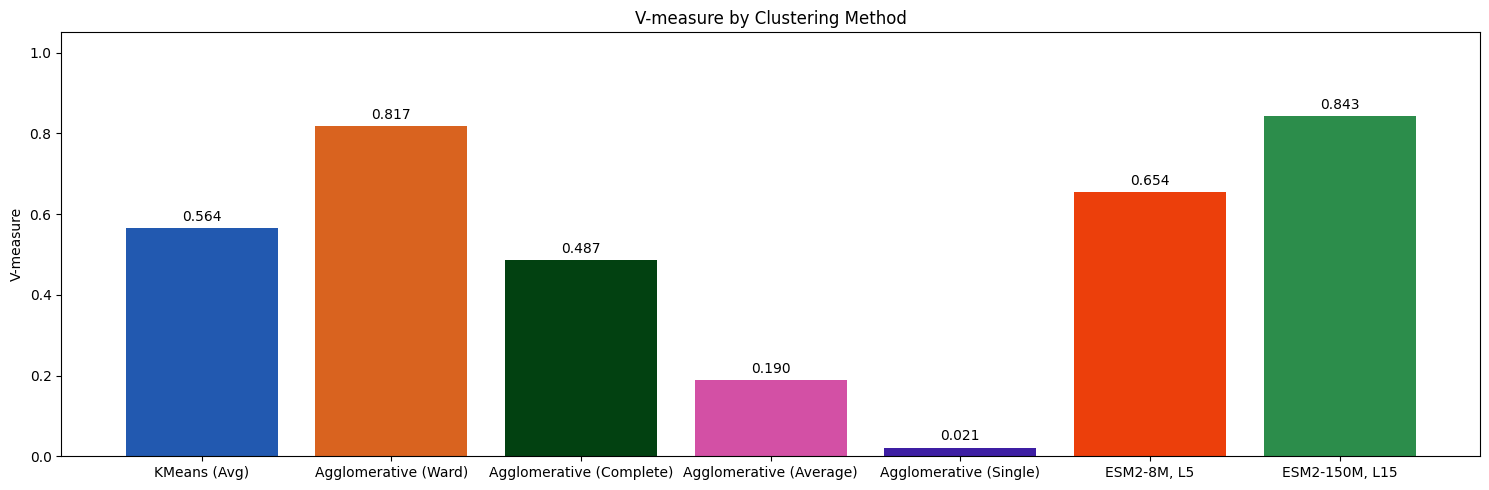

In [ ]:
import matplotlib.pyplot as plt

results_v_measures.append({'ESM2-8M, L5': 0.6537410442469105})
results_v_measures.append({'ESM2-150M, L15': 0.843073317600245})


combined = {}
for d in results_v_measures:
    combined.update(d)

fig, ax = plt.subplots(figsize=(15, 5))
bars = ax.bar(combined.keys(), combined.values(), color=["#2259b0", "#d9631f", "#024111", "#d350a5", "#3d1ea3", "#ec3f0b", "#2c8d4b"])
ax.bar_label(bars, fmt='%.3f', padding=3)
ax.set_ylim(0, 1.05)
ax.set_ylabel('V-measure')
ax.set_title('V-measure by Clustering Method (K-mer and Embeddings)')
plt.tight_layout()
plt.show()


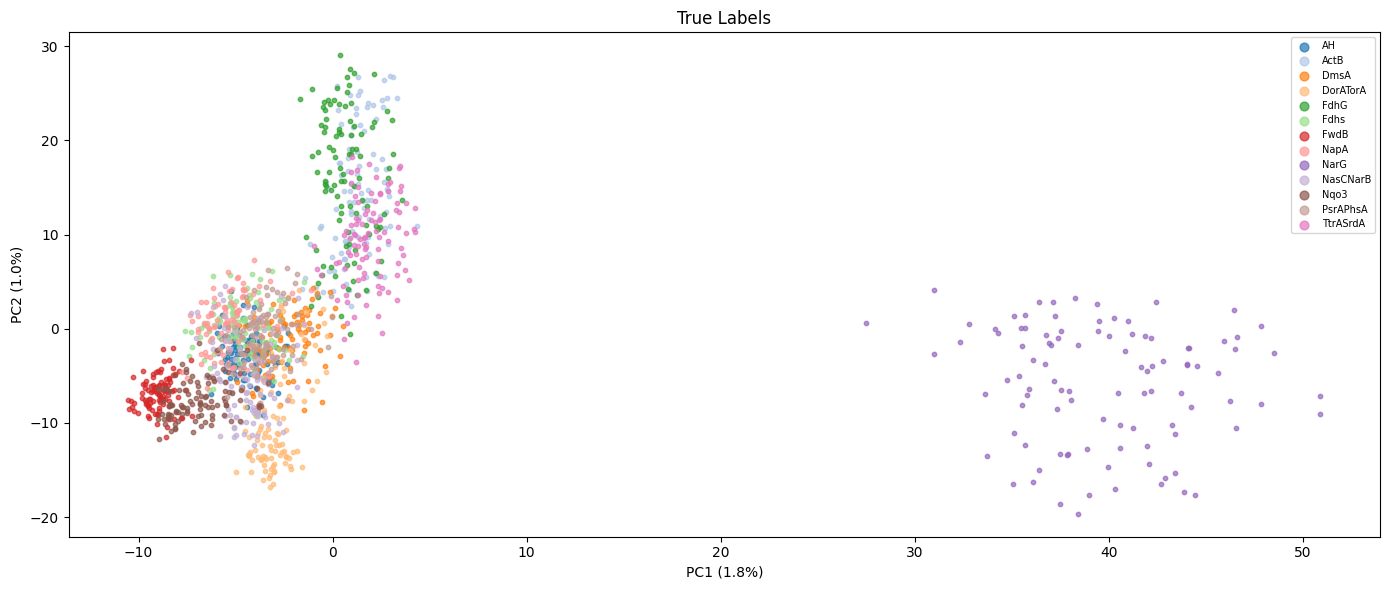

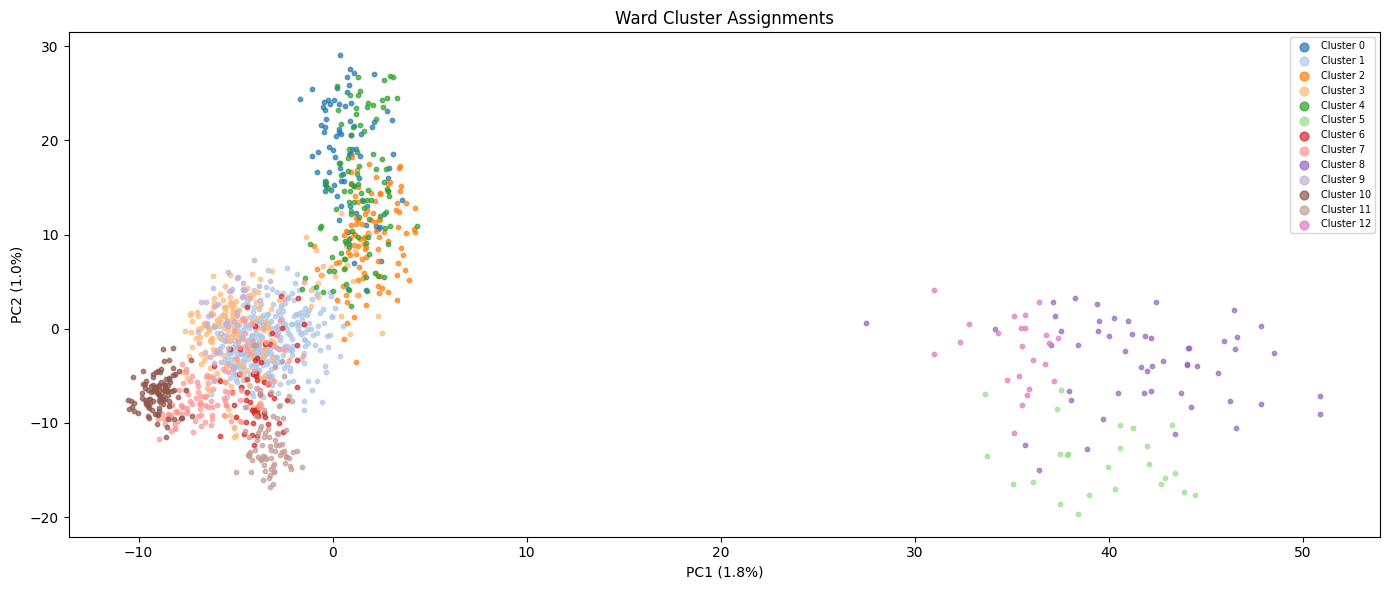

In [ ]:
# PCA scatterplot
pca2d = PCA(n_components=2)
coords = pca2d.fit_transform(df_scaled)

classes = sorted(true_labels.unique())
colors = plt.cm.tab20.colors

fig, ax = plt.subplots(figsize=(14, 6))
for i, cls in enumerate(classes):
    mask = (true_labels == cls).values
    ax.scatter(coords[mask, 0], coords[mask, 1], s=10, color=colors[i], label=cls, alpha=0.7)
ax.set_title('True Labels 2D PCA')
ax.legend(markerscale=2, fontsize=7)
ax.set_xlabel(f'PC1 ({pca2d.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca2d.explained_variance_ratio_[1]*100:.1f}%)')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 6))
for c in sorted(set(agg_ward_labels)):
    mask = agg_ward_labels == c
    ax.scatter(coords[mask, 0], coords[mask, 1], s=10, color=colors[c % len(colors)], label=f'Cluster {c}', alpha=0.7)
ax.set_title('Ward Cluster Assignments 2D PCA')
ax.legend(markerscale=2, fontsize=7)
ax.set_xlabel(f'PC1 ({pca2d.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca2d.explained_variance_ratio_[1]*100:.1f}%)')
plt.tight_layout()
plt.show()


Loading weights: 100%|██████████| 102/102 [00:00<00:00, 6041.62it/s]
[transformers] EsmModel LOAD REPORT from: facebook/esm2_t6_8M_UR50D
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Embedding matrix shape: (1300, 320)
  Explained variance: PC1=0.315, PC2=0.146, Total=0.462


/var/folders/gw/m8q0qy591dng6wh96z5f1pcc0000gn/T/ipykernel_40510/653415311.py:58: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(unique_labels))


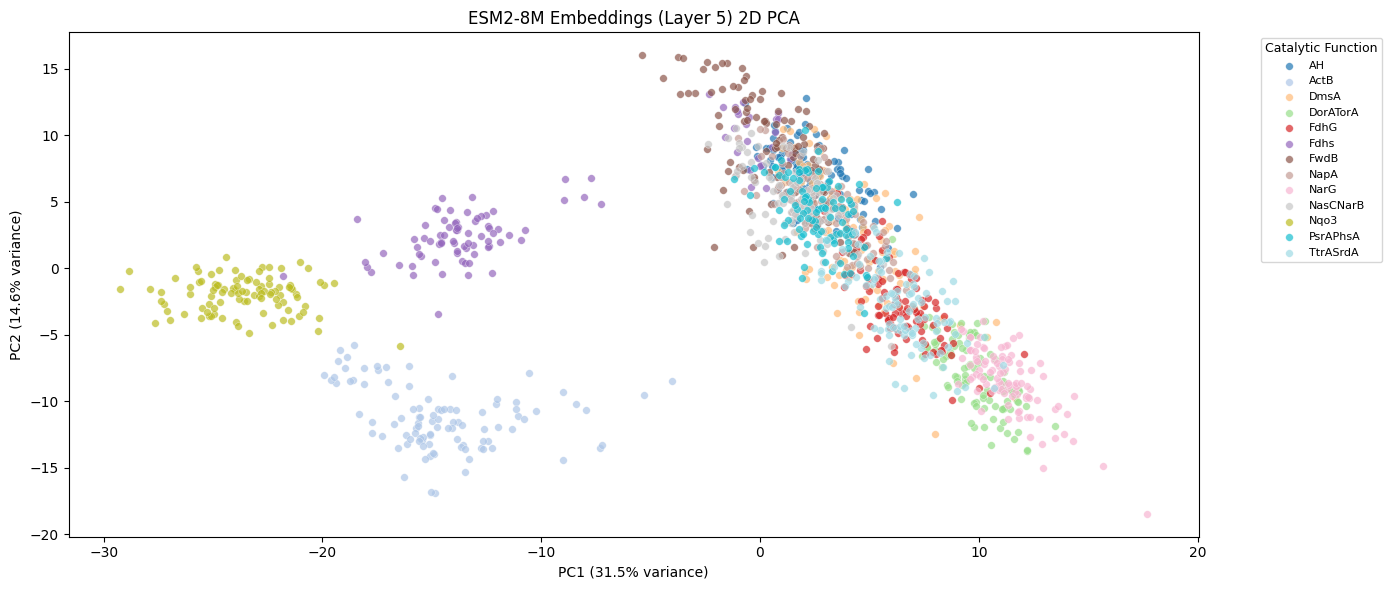

In [24]:
import torch
from transformers import AutoTokenizer, AutoModel

sequences = ds["Sequence"]
labels = ds["Label"]

# Load ESM2-8M
model_name = "facebook/esm2_t6_8M_UR50D"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)
model.eval()

TARGET_LAYER = 5

# Extract embeddings
embeddings = []
batch_size = 8  # small batches to avoid OOM on CPU

for i in range(0, len(sequences), batch_size):
    batch_seqs = sequences[i : i + batch_size]
    
    # tokenize
    inputs = tokenizer(
        batch_seqs,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=1024,
    )
    
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
   
    hidden = outputs.hidden_states[TARGET_LAYER]  # (batch, seq_len, 320)
    
    # mean pool over sequence length
    attention_mask = inputs["attention_mask"].unsqueeze(-1)  # (batch, seq_len, 1)
    masked = hidden * attention_mask
    pooled = masked.sum(dim=1) / attention_mask.sum(dim=1)  # (batch, 320)
    
    embeddings.append(pooled.numpy())


embeddings = np.vstack(embeddings)
print(f"Embedding matrix shape: {embeddings.shape}")

scaler = StandardScaler()
embeddings_scaled = scaler.fit_transform(embeddings)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(embeddings_scaled)

print(f"  Explained variance: PC1={pca.explained_variance_ratio_[0]:.3f}, "
      f"PC2={pca.explained_variance_ratio_[1]:.3f}, "
      f"Total={sum(pca.explained_variance_ratio_):.3f}")

unique_labels = sorted(set(labels))
cmap = plt.cm.get_cmap("tab20", len(unique_labels))

fig, ax = plt.subplots(figsize=(14, 6))

for idx, label in enumerate(unique_labels):
    mask = np.array([l == label for l in labels])
    ax.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        c=[cmap(idx)],
        label=label,
        alpha=0.7,
        s=30,
        edgecolors="white",
        linewidth=0.3,
    )

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax.set_title("ESM2-8M Embeddings (Layer 5) 2D PCA")
ax.legend(
    title="Catalytic Function",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=8,
    title_fontsize=9,
)
plt.tight_layout()
plt.show()